# Check dataset columns

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [2]:

import os
# Change directory to import properly
os.chdir('..')

from src.data_loader import load_besstie, get_train_conditions, get_test_conditions

# Load besstie dataset
ds = load_besstie()

# Look at the format of a besttie entry
print(ds['train'][0])

c:\Users\joela\Documents\code\ai\nlp\NLP-sequence-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}


In [3]:
from datasets import Dataset

from transformers import (
    RobertaForSequenceClassification,
    RobertaTokenizer,
    TrainingArguments,
    Trainer,
)

import torch 
import numpy as np

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

TASK      = "sentiment"
LABEL_COL = "Sentiment"
TEXT_COL  = "text"

MODEL_NAME = "roberta-base"
tokenizer  = RobertaTokenizer.from_pretrained(MODEL_NAME)

# Function to tokenize each bacth of the dataset
def tokenize(batch):
    tokens = tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokens["labels"] = [int(label) for label in batch[LABEL_COL]]

    return tokens

def prepare_dataset(dataset):
    """Tokenizes and formats dataset for trainer"""

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.remove_columns(
        [c for c in tokenized.column_names if c not in
        ["input_ids", "attention_mask", "labels"]]
    )
    
    tokenized.set_format("torch")
    return tokenized

In [20]:
# Functions to compute model accuracy
from sklearn.metrics import (
    f1_score, precision_score,
    recall_score, confusion_matrix,
    classification_report
)

def compute_metrics(eval_pred):
    """Returns macro-F1."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "accuracy": (predictions == labels).mean()
    }

def full_evaluation(y_true, y_pred, task="sarcasm"):
    """Full metrics for report — called after training completes."""
    
    if task == "sentiment":
        class_names = ["Negative", "Positive"]
    else:
        class_names = ["Not Sarcastic", "Sarcastic"]

    return {
        "macro_f1":        round(f1_score(y_true, y_pred, average="macro"), 4),
        "precision":       round(precision_score(y_true, y_pred, average="macro"), 4),
        "recall":          round(recall_score(y_true, y_pred, average="macro"), 4),
        "per_class_f1":    f1_score(y_true, y_pred, average=None).tolist(),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "report":          classification_report(
                                y_true, y_pred,
                                target_names=class_names)
    }

In [18]:
# Code for the weighted trainer

import torch.nn as nn
def calculate_class_weights(dataset, label_col="Sentiment"):
    labels = dataset[label_col]
    n_total = len(labels)
    n_class1 = sum(labels) 
    n_class0 = n_total - n_class1

    # Weights are calculated as: total / (number_of_classes * count_per_class)
    weight_0 = n_total / (2 * n_class0)
    weight_1 = n_total / (2 * n_class1)

    if label_col == "Sentiment":
        label_0, label_1 = "Negative", "Positive"
    else:
        label_0, label_1 = "Not Sarcastic", "Sarcastic"

    print(f"Weights for {label_col}: Class 0 ({label_0}) = {weight_0:.3f}, Class 1 ({label_1}) = {weight_1:.3f}")
    return torch.tensor([weight_0, weight_1], dtype=torch.float)

class WeightedTrainer(Trainer):
    def __init__(self, *args, loss_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Move weights to the same device as the model (CPU or GPU)
        device = logits.device
        weights = self.loss_weights.to(device)
        
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

In [19]:
# Training function - using trainer instead of manual loop
def train_roberta(train_data, val_data, seed=42, output_dir="./tmp"):
    """Fine tunes RoBERTa on given training data. Returns 
    trained model and tokeizer"""

    torch.manual_seed(seed)
    np.random.seed(seed)

    weights = calculate_class_weights(train_data, label_col="Sentiment")

    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    # Tokenize training data and validations values
    train_tokenized = prepare_dataset(train_data)
    val_tokenized = prepare_dataset(val_data)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=1e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        seed=seed,
        report_to="none"
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
        loss_weights=weights
    )

    trainer.train()
    return model, tokenizer

def evaluate_on_testset(model, test_data):
    """Runs trained model on a test set. Returns 
        evaluation metric dict """
    
    test_tokenized = prepare_dataset(test_data)

    test_tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

    trainer = Trainer(model=model)
    output = trainer.predict(test_tokenized)

    y_pred = np.argmax(output.predictions, axis=1)
    y_true = np.array(test_tokenized["labels"])

    return full_evaluation(y_true, y_pred)

In [13]:
print("Train columns:", ds["train"].column_names)

Train columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


In [14]:
# Experiment loop
from tqdm import tqdm
import json

os.makedirs("weighted_results2", exist_ok=True)
os.makedirs("weighted_figures2", exist_ok=True)

all_results = {}
SEEDS = [42, 123]

train_conditions = get_train_conditions(ds)
test_sets = get_test_conditions(ds)
val_data = ds["validation"]

# Training conditions
for condition_name, train_data in tqdm(
    train_conditions.items(),
    desc="Conditions",
    position=0
):
    condition_results = {}

    # Loop for the seeds
    for seed in tqdm(
        SEEDS,
        desc=f" {condition_name}",
        position=1,
        leave=False
    ):
        model, tok = train_roberta(
            train_data, val_data,
            seed=seed,
            output_dir=f"./tmp/{condition_name}_seed{seed}"
        )

        seed_results = {}
        for test_name, test_data in tqdm(
            test_sets.items(),
            desc=f" Evaluating",
            position=2,
            leave=False
        ):
            results = evaluate_on_testset(model, test_data)
            seed_results[test_name] = results

        condition_results[f"seed_{seed}"] = seed_results

    averaged = {}

    for test_name in test_sets.keys():
        f1_scores = [
            condition_results[f"seed_{s}"][test_name]["macro_f1"]
            for s in SEEDS
        ]
        averaged[test_name] = {
            "macro_f1_mean": round(np.mean(f1_scores), 4),
            "macro_f1_std": round(np.std(f1_scores), 4),
        }

    all_results[condition_name] = {
        "by_seed": condition_results,
        "averaged": averaged
    }
    with open(f"weighted_results2/{condition_name}.json", "w") as f:
        json.dump(all_results[condition_name], f, indent=2)

Conditions:   0%|          | 0/5 [00:00<?, ?it/s]

Weights for Sentiment: Class 0 (Not Sarcastic) = 1.028, Class 1 (Sarcastic) = 0.973



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4097.95it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be rem

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.332609,0.887808,0.888179
2,No log,0.227707,0.929591,0.929712
3,No log,0.345314,0.916912,0.916933
4,No log,0.327737,0.916864,0.916933
5,No log,0.367260,0.920098,0.920128




Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder

...

Weights for Sentiment: Class 0 (Not Sarcastic) = 1.028, Class 1 (Sarcastic) = 0.973



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4498.32it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be rem

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.400354,0.862569,0.862620
2,No log,0.287650,0.913734,0.913738
3,No log,0.419099,0.923146,0.923323
4,No log,0.361471,0.919968,0.920128




Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


Conditions:   0%|          | 0/5 [22:34<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Sentiment - All Pool Training

os.makedirs("results/sentiment", exist_ok=True)

SEEDS = [42, 123]
sentiment_results = {}

for seed in tqdm(SEEDS, desc="Seeds"):
    
    # Train on all pool data
    model, tok = train_roberta(
        train_data=ds["train"],
        val_data=ds["validation"],
        seed=seed,
        output_dir=f"./tmp/sentiment_allpool_seed{seed}",
    )
    
    # Test on each variety test set
    seed_results = {}
    for test_name, test_data in tqdm(
        test_sets.items(),
        desc="  Evaluating",
        leave=False
    ):
        results = evaluate_on_testset(model, test_data)
        seed_results[test_name] = results
        print(f"Seed {seed} | {test_name} | "
              f"Macro-F1: {results['macro_f1']:.4f}")
    
    sentiment_results[f"seed_{seed}"] = seed_results

# Average across seeds
averaged = {}
for test_name in test_sets.keys():
    f1_scores = [
        sentiment_results[f"seed_{s}"][test_name]["macro_f1"]
        for s in SEEDS
    ]
    averaged[test_name] = {
        "macro_f1_mean": round(np.mean(f1_scores), 4),
        "macro_f1_std":  round(np.std(f1_scores), 4),
    }

# Save results
final = {"by_seed": sentiment_results, "averaged": averaged}
with open("results/sentiment/all_pool.json", "w") as f:
    json.dump(final, f, indent=2)

print("\nSentiment results saved to results/sentiment/all_pool.json")
print("\nAveraged results:")
for test_name, scores in averaged.items():
    print(f"  {test_name}: {scores['macro_f1_mean']:.4f} "
          f"± {scores['macro_f1_std']:.4f}")

Seeds:   0%|          | 0/2 [00:00<?, ?it/s]

Weights for Sentiment: Class 0 (Negative) = 0.982, Class 1 (Positive) = 1.018


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3746.71it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be remo

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.213321,0.939235,0.939297
2,No log,0.192051,0.920076,0.920128
3,0.350286,0.186423,0.942421,0.942492
4,0.350286,0.212914,0.929712,0.929712
5,0.171674,0.234685,0.936070,0.936102


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Seed 123 | uk_only | Macro-F1: 0.9528


Seed 123 | au_only | Macro-F1: 0.8964


Seeds: 100%|██████████| 2/2 [15:32<00:00, 466.23s/it]

Seed 123 | in_only | Macro-F1: 0.8479

Sentiment results saved to results/sentiment/all_pool.json

Averaged results:
  uk_only: 0.9507 ± 0.0021
  au_only: 0.9008 ± 0.0044
  in_only: 0.8545 ± 0.0066


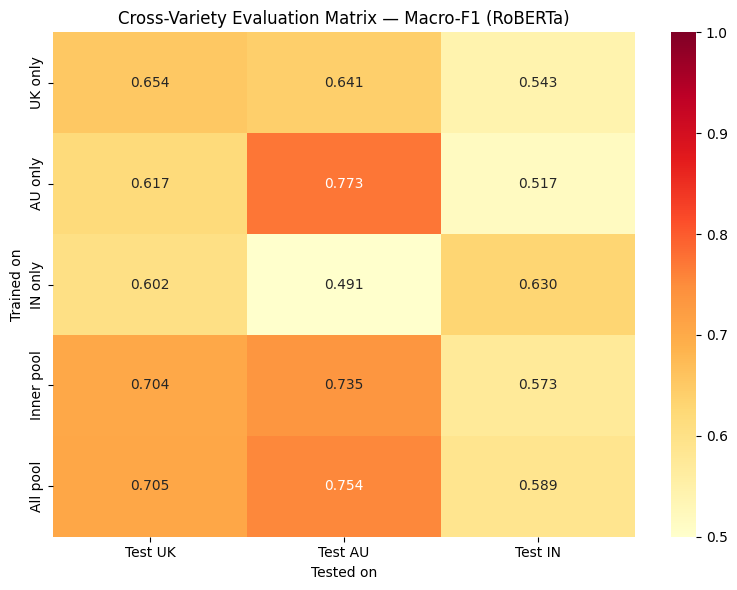


Cross-Variety Matrix:
            Test UK  Test AU  Test IN
UK only      0.6539   0.6410   0.5434
AU only      0.6172   0.7733   0.5168
IN only      0.6023   0.4906   0.6302
Inner pool   0.7038   0.7345   0.5726
All pool     0.7051   0.7545   0.5890


In [ ]:
# Results Visualisation (incl cross variety matrix)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

conditions = list(train_conditions.keys())
test_names = list(test_sets.keys())

matrix = np.array([
    [all_results[c]["averaged"][t]["macro_f1_mean"]
    for t in test_names]
    for c in conditions
])

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt='.3f',
    xticklabels=["Test UK", "Test AU", "Test IN"],
    yticklabels=["UK only", "AU only", "IN only",
                 "Inner pool", "All pool"],
    cmap="YlOrRd",
    vmin=0.5, vmax=1.0
)
plt.title("Cross-Variety Evaluation Matrix — Macro-F1 (RoBERTa)")
plt.ylabel("Trained on")
plt.xlabel("Tested on")
plt.tight_layout()
plt.savefig("weighted_figures2/cross_variety_matrix.png", dpi=150)
plt.show()

results_df = pd.DataFrame(
    matrix,
    index=["UK only", "AU only", "IN only", "Inner pool", "All pool"],
    columns=["Test UK", "Test AU", "Test IN"]
)
print("\nCross-Variety Matrix:")
print(results_df.to_string())

Best condition: all


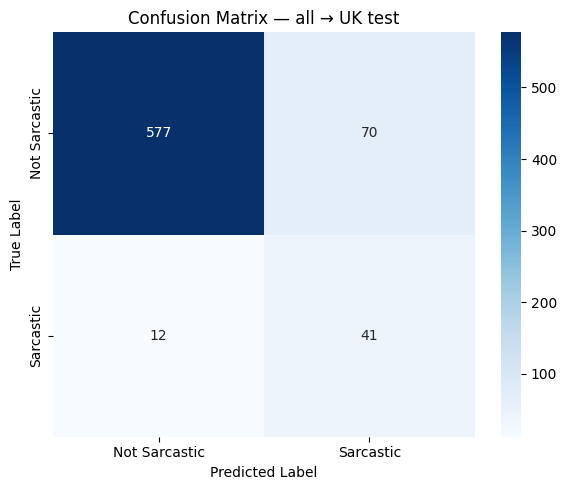

In [ ]:
# Find confusion matrix for best conditions
best_condition = max(
    conditions,
    key=lambda c: np.mean([
        all_results[c]["averaged"][t]["macro_f1_mean"]
        for t in test_names
    ])
)
print(f"Best condition: {best_condition}")

best_cm = np.array(
    all_results[best_condition]["by_seed"]["seed_42"][test_names[0]]["confusion_matrix"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_condition} → UK test")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("weighted_figures2/confusion_matrix_best.png", dpi=150)
plt.show()